# 01 — Introduction to Map Encryption

## Problem Statement

GPS coordinates are quasi-identifying even without names attached. A sequence of locations — home, workplace, hospital, place of worship — can uniquely fingerprint an individual. Standard field-level encryption (e.g., AES-ECB on the raw bytes) is not enough: spatial range queries against stored tile indices `(qxp, qyp)` can reveal areas of interest without ever decrypting, simply by observing which index values cluster within a bounding box.

This scheme addresses the problem with a four-step pipeline:

| Step | Name | What it does |
|------|------|--------------|
| 1 | **Project** | Convert (lat, lon) to Web Mercator (x, y) in metres |
| 2 | **Snap + Shuffle** | Round to a 250 m grid tile; permute tile indices with a Feistel PRP |
| 3 | **Lock** | AEAD-encrypt the sub-tile residual (rx, ry) |
| 4 | **Wobble** | Add per-record jitter for display; jitter_key only needed |

## Glossary

| Term | Meaning |
|------|---------|
| **Web Mercator** | EPSG:3857 cylindrical projection; maps (lat, lon) to metres (x, y) |
| **Tile** | 250 m × 250 m cell in the projected grid |
| **PRP** | Pseudorandom Permutation — a keyed bijection on a finite set |
| **Feistel** | Network of round functions that constructs a PRP from a PRF |
| **AEAD** | Authenticated Encryption with Associated Data |
| **Nonce** | Number used once; random 12-byte value generated per encode call |
| **Tweak** | Per-record context bytes bound into both the PRP and AEAD |
| **Residual** | Sub-tile offset (rx, ry); stores full GPS precision within the tile |
| **Key derivation** | Generating independent subkeys from one master key (HKDF-style) |
| **Rejection sampling** | Discarding biased hash outputs to achieve uniform distribution |

In [1]:
import secrets
import math
import numpy as np
import matplotlib.pyplot as plt

from map_encryption import (
    MapEncryption, SchemeParams, SCHEME_VERSION,
    _R_EARTH, _CHACHA_AVAILABLE,
)

print(f'Scheme version: {SCHEME_VERSION}')
print(f'AEAD backend: {"ChaCha20-Poly1305 (cryptography)" if _CHACHA_AVAILABLE else "XOR+HMAC-SHA256 (fallback)"}')

def metres_to_deg(spread_m, at_lat):
    """Approximate conversion from metres to degrees at a given latitude."""
    lat_deg = spread_m / 111_320
    lon_deg = spread_m / (111_320 * math.cos(math.radians(at_lat)))
    return lat_deg, lon_deg

# in production: load from secrets manager
MASTER_KEY = secrets.token_bytes(32)
enc = MapEncryption(MASTER_KEY, SchemeParams())
print(f'MapEncryption instance created with bin_size_m={enc.params.bin_size_m}')

Scheme version: 1
AEAD backend: ChaCha20-Poly1305 (cryptography)
MapEncryption instance created with bin_size_m=250


In [2]:
CENTER_LAT, CENTER_LON = 51.513341, -0.136668  # Broadwick Street pump, Soho, London (1854 cholera outbreak)

tweak = MapEncryption.make_tweak(record_id=1, extra=b'nb01-demo')
record = enc.encode(CENTER_LAT, CENTER_LON, tweak=tweak)

print('Encoded record fields:')
print(f'  qxp       = {record["qxp"]}  (shuffled tile x-index)')
print(f'  qyp       = {record["qyp"]}  (shuffled tile y-index)')
print(f'  nonce     = {record["nonce"].hex()}  (12-byte random nonce)')
print(f'  ct_resid  = {record["ct_resid"].hex()[:32]}...  (encrypted sub-tile offset)')
print(f'  tweak     = {record["tweak"].hex()}  (record-binding context)')
print(f'  version   = {record["version"]}  (scheme version)')

decoded = enc.decode(record)
assert decoded is not None, 'decode returned None unexpectedly'
dlat, dlon = decoded
err = max(abs(dlat - CENTER_LAT), abs(dlon - CENTER_LON))
print(f'\nRound-trip error: {err:.2e} degrees')

Encoded record fields:
  qxp       = -72512  (shuffled tile x-index)
  qyp       = -25241  (shuffled tile y-index)
  nonce     = 603002b00853c15ff5de4992  (12-byte random nonce)
  ct_resid  = d153a4d2e3de39ec7e2b34cdc330e601...  (encrypted sub-tile offset)
  tweak     = 0000000000000001000000016e6230312d64656d6f  (record-binding context)
  version   = 1  (scheme version)

Round-trip error: 7.11e-15 degrees


## Record Field Reference

| Field | Type | Size | Is it secret? | Purpose |
|-------|------|------|---------------|---------|
| `qxp` | int | 4–8 bytes | No — but opaque | Shuffled tile x-index; reveals nothing without PRP key |
| `qyp` | int | 4–8 bytes | No — but opaque | Shuffled tile y-index; reveals nothing without PRP key |
| `nonce` | bytes | 12 bytes | No — public | Unique per encode call; seeds AEAD and display jitter |
| `ct_resid` | bytes | 32 bytes | **Yes** | AEAD ciphertext of (rx, ry); holds full GPS precision |
| `tweak` | bytes | variable | No — public | Record-ID context; binds ciphertext to this record |
| `version` | int | 1 byte | No | Scheme version for forward-compatible migration |

**Key point:** only `ct_resid` is truly secret. Everything else can be stored in plain sight — it reveals no location without the keys.

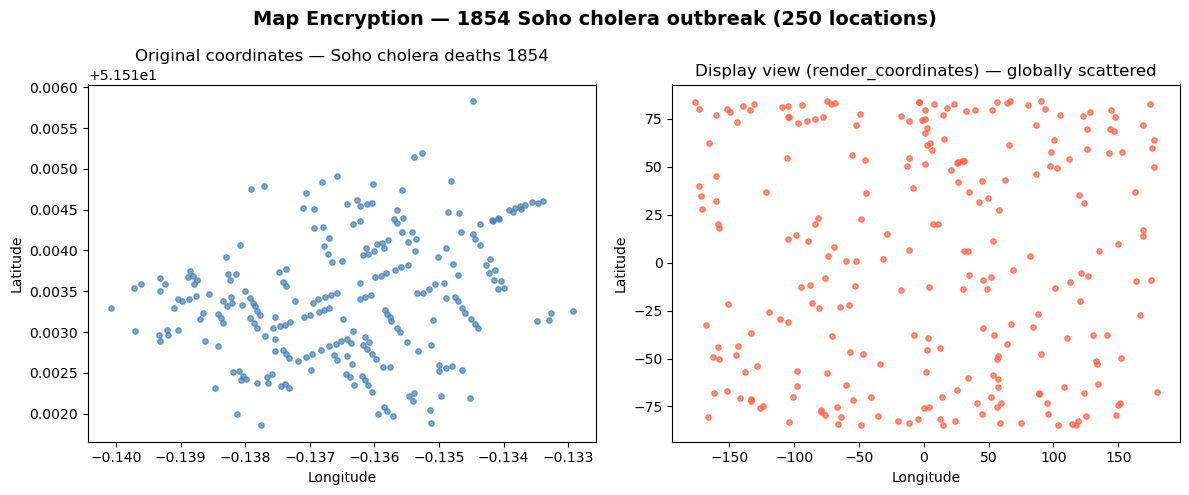

Encoded and rendered 250 cholera death locations (Soho, London 1854).


In [3]:
import pandas as pd

deaths = pd.read_csv('data/cholera_deaths.csv')
n = len(deaths)  # 250 death locations recorded by Dr. John Snow
lats = deaths['LAT'].values
lons = deaths['LON'].values

records = [
    enc.encode(lats[i], lons[i],
               tweak=MapEncryption.make_tweak(record_id=int(deaths['FID'].iloc[i]),
                                              extra=b'nb01-demo'))
    for i in range(n)
]

display_positions = [enc.render_coordinates(r) for r in records]
disp_lats = [p[0] for p in display_positions]
disp_lons = [p[1] for p in display_positions]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(lons, lats, s=15, color='steelblue', alpha=0.7)
axes[0].set_title('Original coordinates — Soho cholera deaths 1854')
axes[0].set_xlabel('Longitude'); axes[0].set_ylabel('Latitude')

axes[1].scatter(disp_lons, disp_lats, s=15, color='tomato', alpha=0.7)
axes[1].set_title('Display view (render_coordinates) — globally scattered')
axes[1].set_xlabel('Longitude'); axes[1].set_ylabel('Latitude')

fig.suptitle('Map Encryption — 1854 Soho cholera outbreak (250 locations)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Encoded and rendered {n} cholera death locations (Soho, London 1854).')


## What Comes Next

- **NB02 — Coordinate Projection**: Deep-dive into the Web Mercator formula and why a projected metre-based grid is necessary for uniform tile sizing.
- **NB03 — Grid Snapping and the Feistel PRP**: How points are snapped to tiles and how the Feistel network shuffles tile indices without losing injectivity.
- **NB04 — Residual Encryption with AEAD**: How ChaCha20-Poly1305 protects the sub-tile offset and why tamper detection is essential.
- **NB05 — Key Derivation and Display Jitter**: How three independent subkeys are derived and how jitter prevents co-location fingerprinting.
- **NB06 — The Complete Pipeline**: End-to-end walkthrough using only the public API across 500 synthetic points.
- **NB07 — Security Properties and Limitations**: Honest inventory of what the scheme protects, what it does not, and directions for improvement.

## References

- **Snow, J.** (1855). *On the Mode of Communication of Cholera* (2nd ed.). Churchill, London. — Source of the 1854 Soho cholera death and pump location dataset used throughout these notebooks.
- **Brody, H., Rip, M.R., Vinten-Johansen, P., Paneth, N., & Rachman, S.** (2000). Map-making and myth-making in Broad Street: the London cholera epidemic, 1854. *The Lancet, 356*(9223), 64–68.
- **Lin, J.** (2023). Geo-indistinguishable masking: enhancing privacy protection in spatial point mapping. See `docs/Geo-indistinguishablemaskingenhancingprivacyprotectioninspatialpointmapping.pdf`.